## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Roshan Mahesh

**Date:** 10/02/26

(338, 4)
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object
Missing values:
 voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_ty

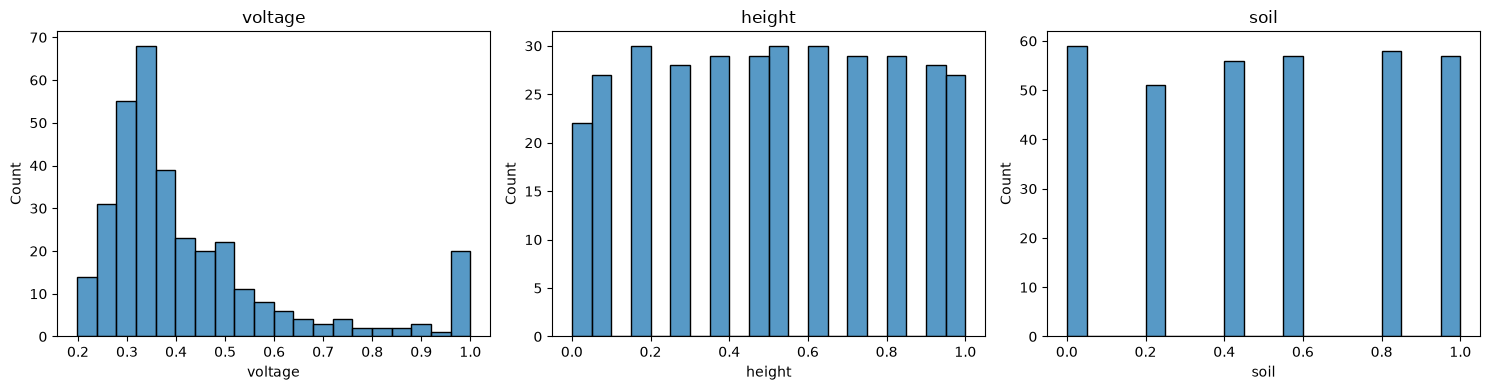

soil
0.0    59
0.2    51
0.4    56
0.6    57
0.8    58
1.0    57
Name: count, dtype: int64
12 distinct height values
          voltage        height          soil       
             mean    std   mean    std   mean    std
mine_type                                           
1           0.296  0.032  0.496  0.316  0.493  0.341
2           0.721  0.222  0.487  0.311  0.509  0.345
3           0.402  0.098  0.528  0.296  0.497  0.351
4           0.345  0.093  0.507  0.306  0.503  0.348
5           0.380  0.076  0.530  0.306  0.517  0.346


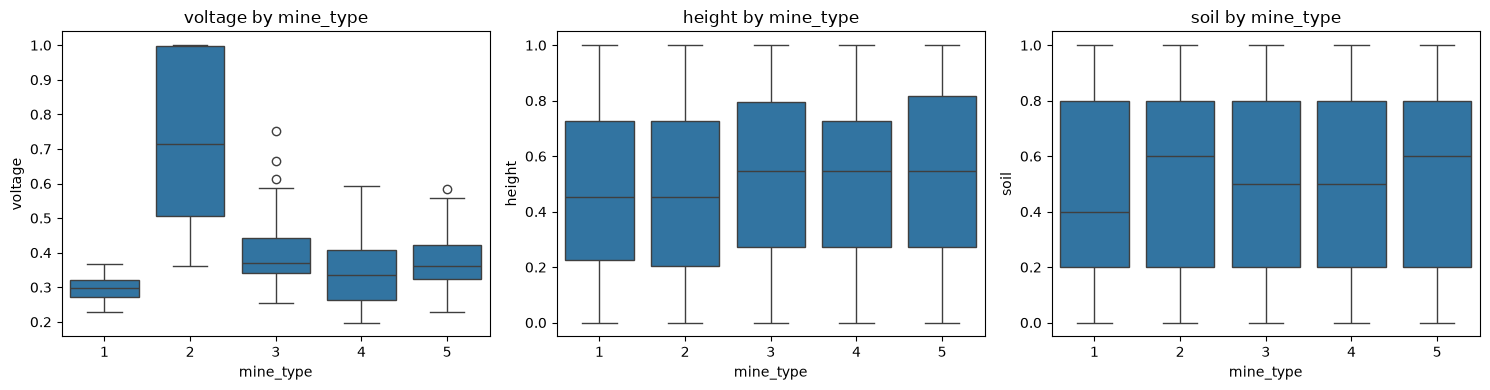

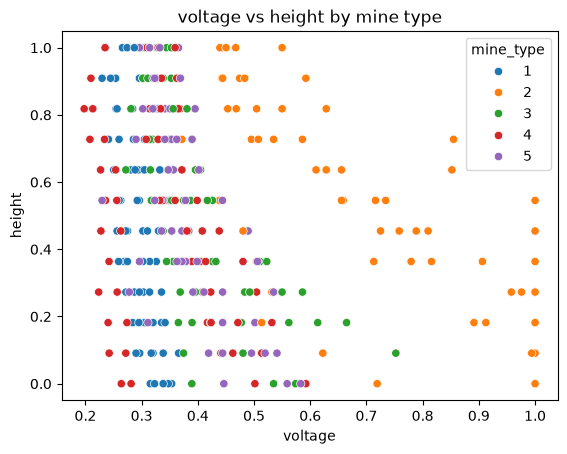

         voltage  height   soil
voltage    1.000  -0.378  0.071
height    -0.378   1.000 -0.007
soil       0.071  -0.007  1.000
(169, 3) (169, 3)
           train  test
mine_type             
1             35    36
2             35    35
3             33    33
4             33    33
5             33    32
Optimal k: 3 | test accuracy: 0.491


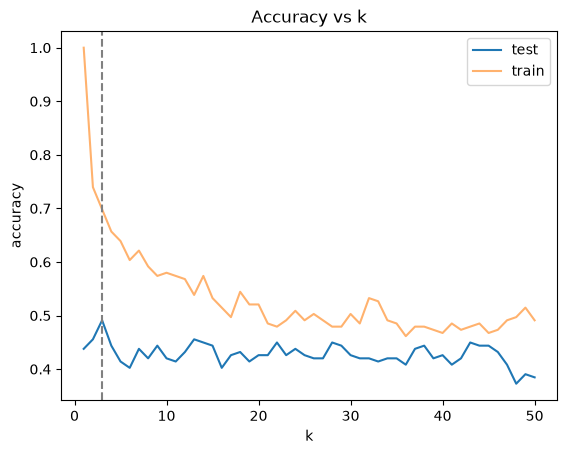

Best accuracy, raw features: 0.432 at k = 3
Best accuracy, standardized: 0.491 at k = 3
Predicted   1   2   3  4  5
Actual                     
1          27   0   4  2  3
2           0  30   1  3  1
3          12   3  11  1  6
4          10   2   8  9  4
5           9   1  13  3  6
Overall accuracy: 0.491
   n_actual  recall  n_predicted  precision
1        36   0.750           58      0.466
2        35   0.857           36      0.833
3        33   0.333           37      0.297
4        33   0.273           18      0.500
5        32   0.188           20      0.300


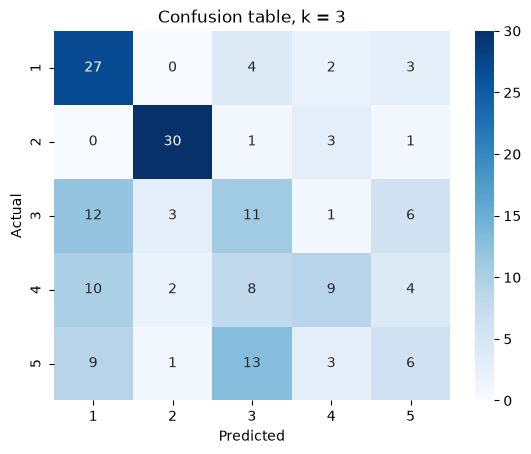

Actual mines in test set: 133
Mines predicted as type 1 (no mine): 31 (23.3%)
Share of type 1 predictions that are actually mines: 53.4%
   threshold  called clear  mines called clear  true no-mine called clear
0        0.3            48                  26                         22
1        0.5             5                   3                          2
2        0.7             0                   0                          0
3        0.9             0                   0                          0
Top-1 accuracy: 0.444
Top-2 accuracy: 0.657


In [7]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
#2.1
df = pd.read_csv('data/land_mines.csv')
print(df.shape)
print(df.head())
print(df.dtypes)
print('Missing values:\n', df.isna().sum())
print(df.describe())

# Target label
print(df['mine_type'].value_counts().sort_index())
print(df['mine_type'].value_counts(normalize=True).sort_index().round(3))

# Feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['voltage', 'height', 'soil']):
    sns.histplot(df[col], bins=20, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(df['soil'].value_counts().sort_index())
print(df['height'].nunique(), 'distinct height values')

# Features by mine type
print(df.groupby('mine_type')[['voltage', 'height', 'soil']].agg(['mean', 'std']).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['voltage', 'height', 'soil']):
    sns.boxplot(data=df, x='mine_type', y=col, ax=ax)
    ax.set_title(f'{col} by mine_type')
plt.tight_layout()
plt.show()

sns.scatterplot(data=df, x='voltage', y='height', hue='mine_type', palette='tab10')
plt.title('voltage vs height by mine type')
plt.show()
print(df[['voltage', 'height', 'soil']].corr().round(3))
#2.2
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=100, stratify=y)

print(X_train.shape, X_test.shape)
print(pd.DataFrame({'train': y_train.value_counts().sort_index(),
                    'test': y_test.value_counts().sort_index()}))

# Standardize features (fit on train only to avoid leakage)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
#2.3
k_grid = np.arange(1, 51)
test_acc, train_acc = [], []
for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    test_acc.append(model.score(X_test_s, y_test))
    train_acc.append(model.score(X_train_s, y_train))
test_acc, train_acc = np.array(test_acc), np.array(train_acc)

k_star = int(k_grid[np.argmax(test_acc)])
print('Optimal k:', k_star, '| test accuracy:', round(test_acc.max(), 3))

plt.plot(k_grid, test_acc, label='test')
plt.plot(k_grid, train_acc, label='train', alpha=0.6)
plt.axvline(k_star, ls='--', c='gray')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.legend()
plt.title('Accuracy vs k')
plt.show()
raw_acc = [KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).score(X_test, y_test)
           for k in k_grid]
print('Best accuracy, raw features:', round(max(raw_acc), 3), 'at k =', int(k_grid[np.argmax(raw_acc)]))
print('Best accuracy, standardized:', round(test_acc.max(), 3), 'at k =', k_star)
#2.4
best = KNeighborsClassifier(n_neighbors=k_star).fit(X_train_s, y_train)
y_hat = best.predict(X_test_s)

ct = pd.crosstab(y_test, y_hat, rownames=['Actual'], colnames=['Predicted'])
print(ct)
print('Overall accuracy:', round((y_hat == y_test).mean(), 3))

per_class = pd.DataFrame({
    'n_actual': ct.sum(axis=1),
    'recall': (np.diag(ct) / ct.sum(axis=1)).round(3),
    'n_predicted': ct.sum(axis=0),
    'precision': (np.diag(ct) / ct.sum(axis=0)).round(3)})
print(per_class)

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion table, k = {k_star}')
plt.show()
#2.5
actual_mine = y_test != 1
pred_clear = y_hat == 1
missed = (actual_mine & pred_clear).sum()
print(f'Actual mines in test set: {actual_mine.sum()}')
print(f'Mines predicted as type 1 (no mine): {missed} ({missed / actual_mine.sum():.1%})')
print(f'Share of type 1 predictions that are actually mines: {missed / pred_clear.sum():.1%}')

# Probability thresholds: only call an area clear when the model is confident
k_prob = 15 
prob_model = KNeighborsClassifier(n_neighbors=k_prob).fit(X_train_s, y_train)
p_clear = prob_model.predict_proba(X_test_s)[:, list(prob_model.classes_).index(1)]

rows = []
for t in [0.3, 0.5, 0.7, 0.9]:
    called_clear = p_clear >= t
    rows.append({'threshold': t,
                 'called clear': called_clear.sum(),
                 'mines called clear': (called_clear & actual_mine).sum(),
                 'true no-mine called clear': (called_clear & ~actual_mine).sum()})
print(pd.DataFrame(rows))

#2.6
proba = prob_model.predict_proba(X_test_s)
top2 = prob_model.classes_[np.argsort(proba, axis=1)[:, -2:]]
print('Top-1 accuracy:', round(prob_model.score(X_test_s, y_test), 3))
print('Top-2 accuracy:', round(np.mean([yt in row for yt, row in zip(y_test, top2)]), 3))



In [8]:
#Question 1
#1. Regression predicts a continuous numeric outcome (like price), while classification predicts a categorical label.
#2. A confusion table cross-tabulates actual vs. predicted class labels, showing not just overall accuracy but which classes the model gets right and which classes it confuses with each other.
#3.SSE measures the total squared distance between a model's predictions and the actual values, so it quantifies how far off the model's predictions are overall, with large errors penalized most heavily.
#4. Overfitting is when a model is too flexible and learns noise in the training data, so it does poorly on new data, while underfitting is when a model is too simple to capture the real pattern, so it does poorly on both training and new data.
#5. Evaluating each k on held-out test data shows how well the model generalizes to data it hasn't seen, so choosing the k with the best test performance avoids both overfitting (k too small) and underfitting (k too large).
#6. A class label is simple and directly actionable but hides how confident the model is, while a probability distribution shows uncertainty and lets you set thresholds based on the cost of different errors, but it is harder to interpret and act on.

#Question 2
#1: The 338 rows have no missing values and the five mine types are nearly balanced, with voltage being the only feature that clearly differs across types (type 2 is much higher) while height and soil look the same for every type.
#3: I chose k = 3 because it gave the highest test-set accuracy out of every k from 1 to 50.
#4: The model is about 49% accurate, doing well on types 1 and 2 but poorly on types 3, 4 and 5, which it often confuses with each other and with type 1.
#5: Since the model often labels real mines as type 1 (no mine), it should only be used to help prioritize and prepare, never to declare an area safe without confirming with another detection method.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 54e1ef875769f11698da1927d96ffbec91ee11d2
- **AI tool and model used:** ChatGPT 6.1 Sol

### *Prompts used

1. How can this be revised to ensure all parts are answered properly?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Add Q2.2’s written answer explaining the stratified 50/50 split.
2. Explain why features are standardized using training data only.
3. Clarify that choosing \(k\) on the held-out set makes it a validation set.
4. Explain why \(k=3\) was selected from values 1–50.
5. Include all five labels in the confusion table and handle division by zero.
6. Report overall accuracy and identify the strongest and weakest classes.
7. Explain precision versus recall using type 1’s results.
8. Use the missed-mine counts to explain the model’s practical limitations.
9. Justify \(k=15\) for probability predictions or use the selected \(k\).
10. Explain probability limitations and label Q2.6 as optional analysis.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Adds the missing explanation; output confirms 169 observations in each set. |
| 2 | Accept | Explains scaling; code fits the scaler on training data only. |
| 3 | Accept | The held-out set is used for validation because it selects k. |
| 4 | Accept | Output confirms k=3 gives the highest accuracy among values 1–50. |
| 5 | Accept | Handles missing predictions and zero denominators; check all five labels appear. |
| 6 | Accept | Output shows 49.1% accuracy, with type 2 strongest and type 5 weakest by recall. |
| 7 | Accept | Type 1’s 75.0% recall and 46.6% precision explain why both metrics matter. |
| 8 | Accept | Output shows 31 mines predicted as no mine, supporting independent confirmation. |
| 9 | Modify | Use the selected k=3 for consistency and rerun the probability analysis. |
| 10 | Accept | Clarifies probability limitations and labels top-two analysis as optional. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Shape: (338, 4)
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object
Missing values:
 voltage      0
height       0
soil         0
mine_type    0
dtype: int64
Feature summary:
           voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
Class counts:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Class proportions:
 mine_type
1    0.210
2    0.207
3    0.195
4    0.195
5

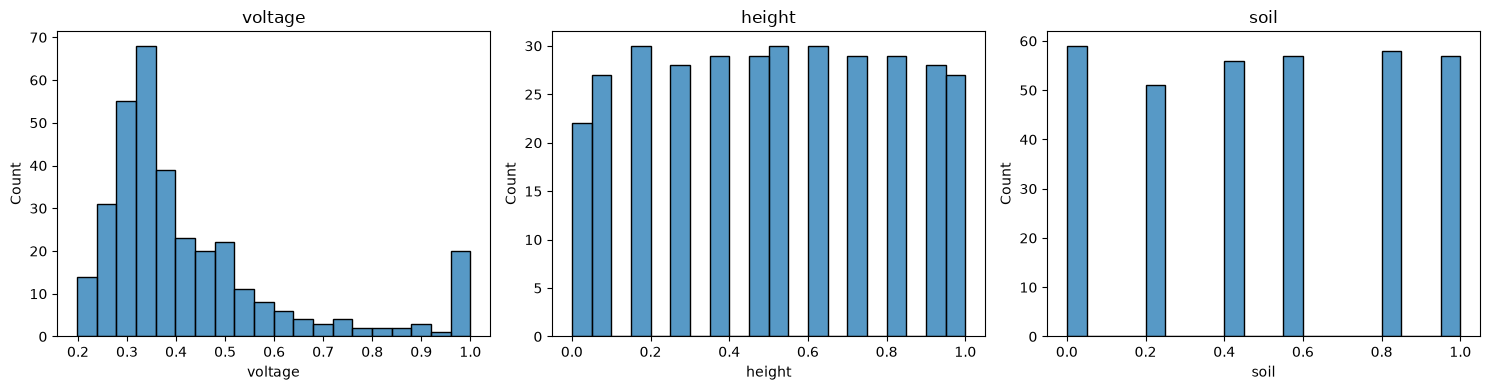

Soil values:
 soil
0.0    59
0.2    51
0.4    56
0.6    57
0.8    58
1.0    57
Name: count, dtype: int64
Distinct height values: 12
Features by mine type:
           voltage        height          soil       
             mean    std   mean    std   mean    std
mine_type                                           
1           0.296  0.032  0.496  0.316  0.493  0.341
2           0.721  0.222  0.487  0.311  0.509  0.345
3           0.402  0.098  0.528  0.296  0.497  0.351
4           0.345  0.093  0.507  0.306  0.503  0.348
5           0.380  0.076  0.530  0.306  0.517  0.346


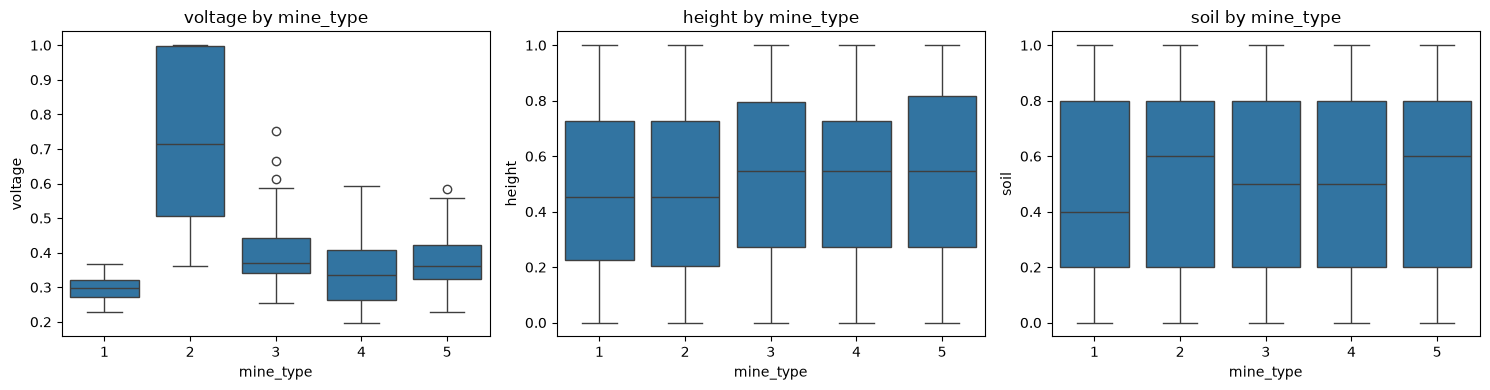

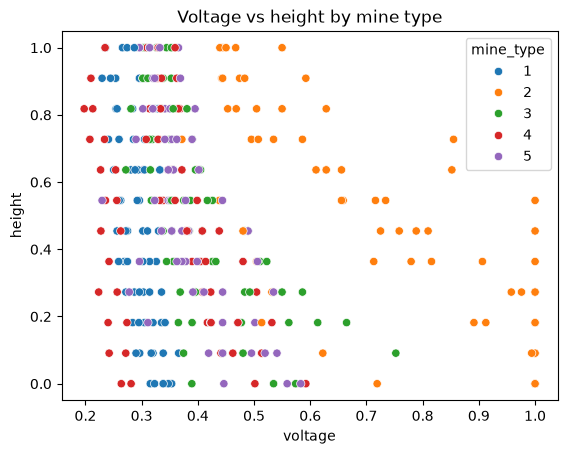

Feature correlations:
          voltage  height   soil
voltage    1.000  -0.378  0.071
height    -0.378   1.000 -0.007
soil       0.071  -0.007  1.000
Training shape: (169, 3)
Validation shape: (169, 3)
           train  validation
mine_type                   
1             35          36
2             35          35
3             33          33
4             33          33
5             33          32
Selected k: 3
Best validation accuracy: 0.491


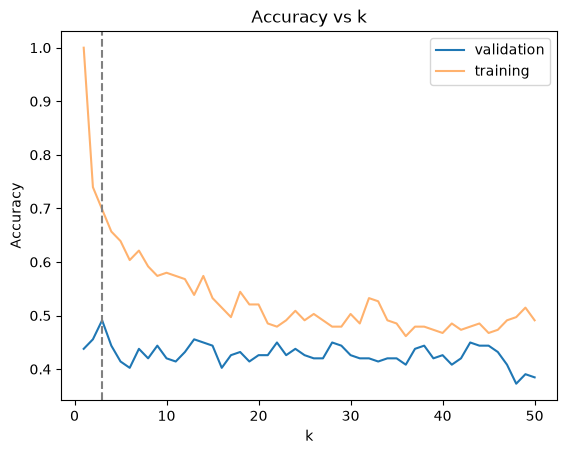

Confusion table:
 Predicted   1   2   3  4  5
Actual                     
1          27   0   4  2  3
2           0  30   1  3  1
3          12   3  11  1  6
4          10   2   8  9  4
5           9   1  13  3  6
Overall validation accuracy: 49.1%
Class performance:
    n_actual  recall  n_predicted  precision
1        36   0.750           58      0.466
2        35   0.857           36      0.833
3        33   0.333           37      0.297
4        33   0.273           18      0.500
5        32   0.188           20      0.300


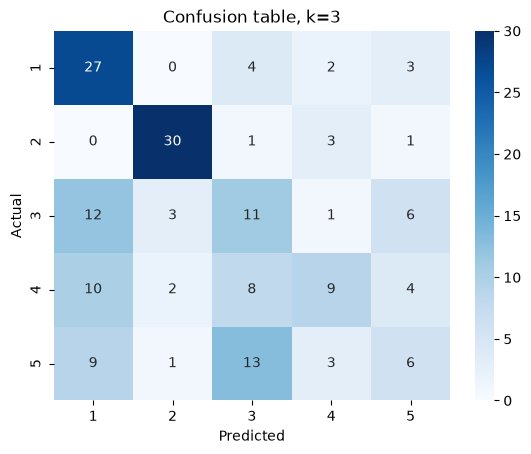

Actual mines: 133
Mines predicted as no mine: 31
Share of actual mines missed: 23.3%
Share of no-mine predictions that are mines: 53.4%
Probability threshold analysis:
    threshold  called clear  mines called clear  true no-mine called clear
0        0.3            77                  46                         31
1        0.5            23                   8                         15
2        0.7             4                   0                          4
3        0.9             4                   0                          4
Top-one validation accuracy: 49.1%
Top-two validation accuracy: 63.3%


In [9]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Question 1
# 1. Regression predicts a continuous numeric outcome, while classification predicts a categorical label.
# 2. A confusion table compares actual and predicted labels, showing correct predictions and which classes are confused.
# 3. SSE is the sum of squared differences between predictions and actual values, with larger errors penalized more heavily.
# 4. Overfitting means learning training noise and performing poorly on new data; underfitting means missing patterns and performing poorly on both.
# 5. Held-out data helps choose a k that generalizes well, but does not guarantee avoiding overfitting or underfitting.
#    A set used to select k is a validation set; an independent test set is needed for a final evaluation.
# 6. Class labels are easy to interpret but hide uncertainty. Probability distributions show uncertainty and support thresholds,
#    but are harder to interpret, and k-NN vote proportions may not be calibrated probabilities.

# Question 2

# 2.1: Load the data and summarize the target and features.
df = pd.read_csv("data/land_mines.csv")
features = ["voltage", "height", "soil"]
labels = [1, 2, 3, 4, 5]

print("Shape:", df.shape)
print(df.head())
print(df.dtypes)
print("Missing values:\n", df.isna().sum())
print("Feature summary:\n", df[features].describe())

print("Class counts:\n", df["mine_type"].value_counts().sort_index())
print(
    "Class proportions:\n",
    df["mine_type"].value_counts(normalize=True).sort_index().round(3)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, features):
    sns.histplot(df[col], bins=20, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Soil values:\n", df["soil"].value_counts().sort_index())
print("Distinct height values:", df["height"].nunique())

print(
    "Features by mine type:\n",
    df.groupby("mine_type")[features].agg(["mean", "std"]).round(3)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, features):
    sns.boxplot(data=df, x="mine_type", y=col, ax=ax)
    ax.set_title(f"{col} by mine_type")
plt.tight_layout()
plt.show()

sns.scatterplot(
    data=df, x="voltage", y="height",
    hue="mine_type", palette="tab10"
)
plt.title("Voltage vs height by mine type")
plt.show()

print("Feature correlations:\n", df[features].corr().round(3))

# The data contain 338 observations with no missing values and nearly balanced classes.
# Voltage shows the clearest differences between classes, especially for type 2.
# Height and soil have similar class means, although they may still help prediction.

# 2.2: Split the data 50/50, preserving class proportions.
X = df[features]
y = df["mine_type"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=100, stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print(pd.DataFrame({
    "train": y_train.value_counts().reindex(labels, fill_value=0),
    "validation": y_val.value_counts().reindex(labels, fill_value=0)
}))

# Each set has 169 observations. Stratification keeps class proportions similar.
# Standardization makes distances reflect variation in each feature.
# Fit the scaler on training data only to avoid leakage.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)

# 2.3: Compare k values and select the highest validation accuracy.
k_grid = np.arange(1, min(50, len(X_train)) + 1)
train_acc = []
val_acc = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_s, y_train)
    train_acc.append(model.score(X_train_s, y_train))
    val_acc.append(model.score(X_val_s, y_val))

val_acc = np.array(val_acc)
k_star = int(k_grid[np.argmax(val_acc)])

print("Selected k:", k_star)
print("Best validation accuracy:", round(val_acc.max(), 3))

plt.plot(k_grid, val_acc, label="validation")
plt.plot(k_grid, train_acc, label="training", alpha=0.6)
plt.axvline(k_star, linestyle="--", color="gray")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.legend()
plt.show()

# k=3 gives the highest validation accuracy among values 1–50.
# If values tie, np.argmax selects the first, which is the smallest k.
# Because this set selects k, its accuracy is a validation result.

# 2.4: Show the confusion table and class-level performance.
best = KNeighborsClassifier(n_neighbors=k_star)
best.fit(X_train_s, y_train)
y_hat = best.predict(X_val_s)

ct = pd.crosstab(
    y_val, y_hat, rownames=["Actual"], colnames=["Predicted"]
).reindex(index=labels, columns=labels, fill_value=0)

correct = pd.Series(np.diag(ct), index=labels)
actual_counts = ct.sum(axis=1)
predicted_counts = ct.sum(axis=0)

per_class = pd.DataFrame({
    "n_actual": actual_counts,
    "recall": correct / actual_counts.replace(0, np.nan),
    "n_predicted": predicted_counts,
    "precision": correct / predicted_counts.replace(0, np.nan)
})

print("Confusion table:\n", ct)
print(f"Overall validation accuracy: {(y_hat == y_val).mean():.1%}")
print("Class performance:\n", per_class.round(3))

sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion table, k={k_star}")
plt.show()

# Overall accuracy is 49.1%. Type 2 has the highest recall at 85.7%.
# Type 5 has the lowest recall at 18.8%, and types 3–5 are frequently confused.
# Recall measures how many actual members of a class are correctly identified.
# Precision measures how many predictions of that class are correct.
# Type 1 has 75.0% recall but only 46.6% precision.

# 2.5: Explain the practical consequences of the errors.
# This interpretation follows the original solution's mapping of type 1 to no mine.
actual_mine = y_val.to_numpy() != 1
pred_clear = y_hat == 1
missed = int((actual_mine & pred_clear).sum())

miss_rate = (
    missed / actual_mine.sum() if actual_mine.sum() else np.nan
)
unsafe_clear_rate = (
    missed / pred_clear.sum() if pred_clear.sum() else np.nan
)

print("Actual mines:", actual_mine.sum())
print("Mines predicted as no mine:", missed)
print(f"Share of actual mines missed: {miss_rate:.1%}")
print(f"Share of no-mine predictions that are mines: {unsafe_clear_rate:.1%}")

# The model predicts 31 actual mines as no mine, missing 23.3% of actual mines.
# Of its no-mine predictions, 53.4% are actually mines.
# Use this model to help prioritize further inspection and prepare for possible mine types.
# Confirm findings with independent detection methods before declaring an area safe.

# Use the selected model for probability analysis.
proba = best.predict_proba(X_val_s)
clear_index = list(best.classes_).index(1)
p_clear = proba[:, clear_index]

rows = []
for threshold in [0.3, 0.5, 0.7, 0.9]:
    called_clear = p_clear >= threshold
    rows.append({
        "threshold": threshold,
        "called clear": int(called_clear.sum()),
        "mines called clear": int((called_clear & actual_mine).sum()),
        "true no-mine called clear": int((called_clear & ~actual_mine).sum())
    })

print("Probability threshold analysis:\n", pd.DataFrame(rows))

# These probabilities are neighbor vote proportions, not guaranteed measures of safety.
# Higher thresholds may reduce clearance predictions, but do not establish safe use.
# A threshold that clears no observations provides no evidence of reliable clearance.

# Optional analysis: top-two accuracy.
top2 = best.classes_[np.argsort(proba, axis=1)[:, -2:]]
top2_accuracy = np.mean([
    actual in predictions
    for actual, predictions in zip(y_val.to_numpy(), top2)
])

print(f"Top-one validation accuracy: {best.score(X_val_s, y_val):.1%}")
print(f"Top-two validation accuracy: {top2_accuracy:.1%}")

# Top-two accuracy counts a prediction as correct when either suggested class matches.
# It can help describe uncertainty, but does not replace ordinary classification accuracy.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]
The AI generated code improves my solution by explaining the modeling choices more clearly and answering each question more directly. It adds an explanation of the stratified 50/50 split, explains why scaling is fitted on training data only, and shows how k = 3 was selected. It also keeps all five labels in the confusion table and handles zero denominators when calculating precision and recall. One limitation I noticed was that the reported accuracy comes from the same set used to choose k, so it is a validation result rather than an independent test result. The revised solution clarifies this and uses the selected k = 3 for probability predictions instead of the unexplained k = 15. I checked the reported results against the existing notebook output and confusion table. The overall accuracy was 49.1%, with type 2 having the highest recall at 85.7% and type 5 having the lowest at 18.8%. The model also predicted 31 actual mines as no mine, meaning 53.4% of its no-mine predictions were incorrect. My main remaining concerns are the low overall accuracy, frequent confusion between mine types, and the danger of treating neighbor vote proportions as reliable confidence estimates